# Persistence — the closure hazard with duration dependence

How long does an arbitrage gap, once open, stay open? The closure branch of the existence model
already answers this as a discrete-time grouped hazard (restrict to `gap_lag > 0`, ask whether
`D_t = 1` — "did the open spell survive this block?"). This notebook adds the one thing it cannot see,
**elapsed time**: `spell_duration`, the blocks the spell has already survived, turning it into a
duration-dependent hazard (Wooldridge Ch. 20). All logic lives in `arblib.estimation`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

quantile=0.2

panel: (644940, 27)


## Build the closure risk set

`build_risk_set(..., condition="closure")` keeps rows where a gap is open at `t-1` (`gap_lag > 0`) with
outcome `D_t` = "the spell survived this block". Each row carries the predetermined `spell_duration`
(spell age at `t-1`) and a `spell_id` for the ongoing spell, so consecutive within-spell rows share a
cluster.

In [2]:
clo = est.build_risk_set(panel, quantile=quantile, condition="closure")


closure: dropping 1 pairs: ['uniswap_2_vs_uniswap_3']
closure: (31067, 15) | D mean: 0.5464 | pairs: 14 | spell_duration max: 30


In [3]:
clo.groupby("pair").size()

pair
pancake_1_vs_pancake_2     3973
uniswap_1_vs_pancake_1     2209
uniswap_1_vs_pancake_2    14923
uniswap_1_vs_uniswap_2      173
uniswap_1_vs_uniswap_3     2658
uniswap_1_vs_uniswap_4      755
uniswap_2_vs_pancake_1       17
uniswap_2_vs_pancake_2      185
uniswap_2_vs_uniswap_4       10
uniswap_3_vs_pancake_1      405
uniswap_3_vs_pancake_2     4647
uniswap_3_vs_uniswap_4      412
uniswap_4_vs_pancake_1      463
uniswap_4_vs_pancake_2      237
dtype: int64

In [4]:
clo = est.drop_pairs_by_event_floor(clo, S.min_events_per_pair, label="closure")
clo["spell_duration"].value_counts().sort_index()

closure: dropping 3 pairs with < 55 rarer-class events (min(n_D0, n_D1)): ['uniswap_1_vs_uniswap_2', 'uniswap_2_vs_pancake_1', 'uniswap_2_vs_uniswap_4']
closure: kept 11 pairs, 30867 rows


spell_duration
1.0     13916
2.0      6262
3.0      3467
4.0      2152
5.0      1400
6.0       939
7.0       676
8.0       500
9.0       361
10.0      266
11.0      212
12.0      154
13.0      116
14.0       84
15.0       65
16.0       55
17.0       44
18.0       41
19.0       34
20.0       27
21.0       22
22.0       18
23.0       15
24.0       13
25.0        9
26.0        6
27.0        5
28.0        5
29.0        2
30.0        1
Name: count, dtype: int64

In [5]:
clo["D"].mean()

np.float64(0.5491949331000745)

In [6]:
clo_c = est.center_continuous(clo, est.CLOSURE_DURATION_TERMS)

dur = est.fit_hazard_logit(clo_c, est.CLOSURE_DURATION_TERMS, cluster="pair")
print(dur.summary())

                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                30867
Model:                          Logit   Df Residuals:                    30825
Method:                           MLE   Df Model:                           41
Date:                Wed, 02 Sep 2026   Pseudo R-squ.:                  0.1204
Time:                        18:40:05   Log-Likelihood:                -18688.
converged:                       True   LL-Null:                       -21246.
Covariance Type:              cluster   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.2724      0.102      2.659      0.008       0.072       0.473
C(pair)[T.uniswap_1_vs_pancake_1]    -1.7531      0.120    -14

In [7]:
est.separation_report(dur, clo_c)

perfectly predicted (fitted p < 0.0001 or > 0.9999): 0 / 30867 obs (0.0%)

fixed-effect dummies by |z| (separation signature = big |coef|, tiny SE), top 8:
                                    coef  std_err   abs_z
C(pair)[T.uniswap_2_vs_pancake_2] -1.111    0.025  44.976
C(pair)[T.uniswap_3_vs_pancake_1] -1.943    0.065  29.937
C(pair)[T.uniswap_1_vs_pancake_1] -1.753    0.120  14.571
C(pair)[T.uniswap_3_vs_uniswap_4] -0.380    0.030  12.577
C(pair)[T.uniswap_1_vs_uniswap_3] -1.743    0.148  11.774
C(pair)[T.uniswap_4_vs_pancake_2] -0.546    0.053  10.253
C(hour)[T.12]                      0.306    0.050   6.141
C(hour)[T.21]                      0.354    0.070   5.039


## Spell-level view — Kaplan–Meier survival (lifelines)

The block-level table above has one row per open block; the classic survival view takes the **spell**
as the unit. `build_spell_table` collapses each canonical spell into one row with `duration` (spell
length in blocks) and `observed` (lifelines' event flag: 1 if closure is seen, 0 if right-censored at
the pair's last block). Descriptive — no fixed effects, keeps every spell.

In [8]:

spells = est.build_spell_table(panel, quantile=quantile)
spells.head()

spells: 14111 | closed: 14111 | censored: 0 | left-truncated: 0 | median duration: 1.0


,pair,onset_block,last_block,duration,observed,left_truncated
0,pancake_1_vs_pancake_2,24551771,24551772,2,1,False
1,pancake_1_vs_pancake_2,24551877,24551877,1,1,False
2,pancake_1_vs_pancake_2,24552086,24552086,1,1,False
3,pancake_1_vs_pancake_2,24552789,24552789,1,1,False
4,pancake_1_vs_pancake_2,24552843,24552844,2,1,False


Fit the Kaplan–Meier estimator on `(duration, observed)` for `S(t) = P(spell still open after t
blocks)`. On this short window nothing is censored, so the curve is the raw empirical survival — the
same call handles right-censoring unchanged on a longer sample.

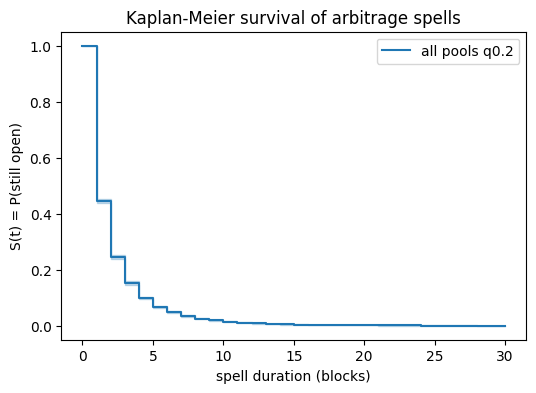

median survival (blocks): 1.0


,all pools q0.2,all pools q0.2_lower_0.95,all pools q0.2_upper_0.95
timeline,,,
0.0,1.0000,1.0000,1.0000
1.0,0.4451,0.4369,0.4533
2.0,0.2460,0.2389,0.2531
3.0,0.1526,0.1467,0.1586
4.0,0.0992,0.0944,0.1042
5.0,0.0665,0.0625,0.0707
6.0,0.0479,0.0445,0.0515
7.0,0.0354,0.0325,0.0386
8.0,0.0256,0.0231,0.0283


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(spells["duration"], event_observed=spells["observed"], label=f"all pools q{quantile}")

ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_xlabel("spell duration (blocks)"); ax.set_ylabel("S(t) = P(still open)")
ax.set_title("Kaplan-Meier survival of arbitrage spells")
plt.show()

print("median survival (blocks):", kmf.median_survival_time_)
kmf.survival_function_.join(kmf.confidence_interval_).round(4)